In [ ]:
import sys
import types
m = types.ModuleType('pyjks')
sys.modules['pyjks'] = m

import os
from dotenv import load_dotenv
import hopsworks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()
API_KEY_HS = os.getenv('API_KEY_HS')

project = hopsworks.login(
    api_key_value=API_KEY_HS,
    project="Pearls_AQI_Predictor12",
    host="eu-west.cloud.hopsworks.ai"
)
fs = project.get_feature_store()
fg = fs.get_feature_group("weather_pollution_features", version=1)

df = fg.read()
print(f"✅ Loaded {len(df)} rows")
df.head()

In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nDate range:", df['event_timestamp'].min(), "→", df['event_timestamp'].max())

In [ ]:
df['aqi'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('AQI Category Distribution (1=Good, 5=Very Poor)')
plt.xlabel('AQI Category')
plt.ylabel('Count')
plt.show()

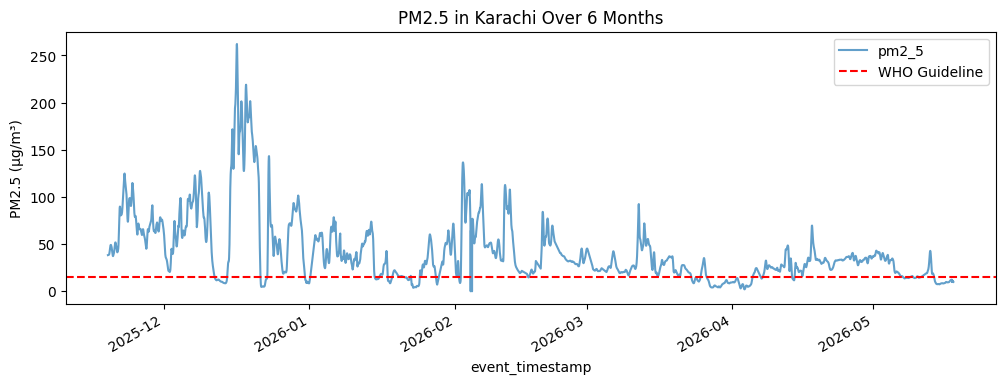

In [4]:
df.set_index('event_timestamp')['pm2_5'].plot(figsize=(12,4), alpha=0.7)
plt.title('PM2.5 in Karachi Over 6 Months')
plt.ylabel('PM2.5 (µg/m³)')
plt.axhline(y=15, color='red', linestyle='--', label='WHO Guideline')
plt.legend()
plt.show()

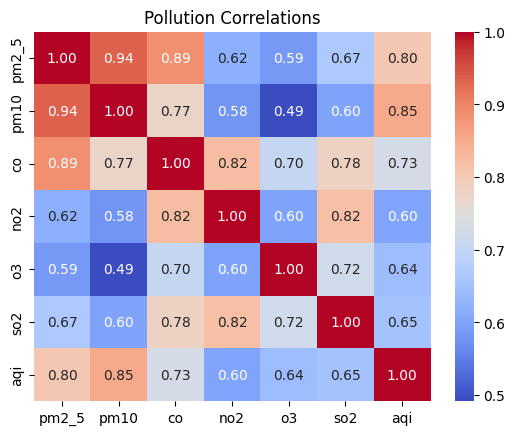

In [5]:
pollution_cols = ['pm2_5', 'pm10', 'co', 'no2', 'o3', 'so2', 'aqi']
sns.heatmap(df[pollution_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pollution Correlations')
plt.show()

In [6]:
df.groupby('hour_of_day')['aqi'].mean().plot(marker='o')
plt.title('Average AQI by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average AQI')
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)
plt.show()

KeyError: 'hour_of_day'

In [7]:
# Ensure datetime
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])

# Add time features
df['hour_of_day'] = df['event_timestamp'].dt.hour
df['day_of_week'] = df['event_timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print("✅ Added: hour_of_day, day_of_week, is_weekend")

✅ Added: hour_of_day, day_of_week, is_weekend


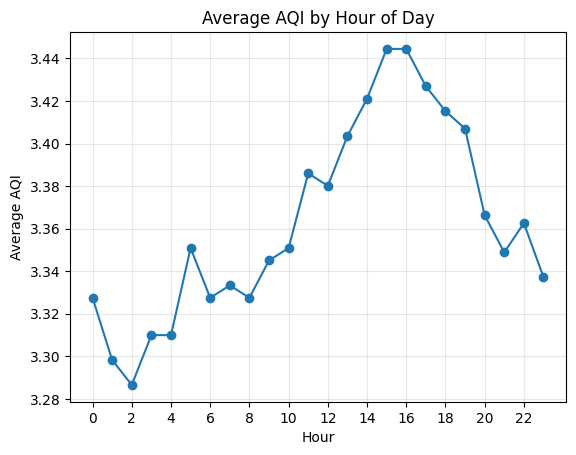

In [8]:
df.groupby('hour_of_day')['aqi'].mean().plot(marker='o')
plt.title('Average AQI by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average AQI')
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
print("AQI Distribution:")
print(df['aqi'].value_counts().sort_index())
print("\nPercentage:")
print((df['aqi'].value_counts(normalize=True).sort_index() * 100).round(1))

AQI Distribution:
aqi
1      78
2     476
3    1996
4     993
5     565
Name: count, dtype: int64

Percentage:
aqi
1     1.9
2    11.6
3    48.6
4    24.2
5    13.8
Name: proportion, dtype: float64


In [10]:
poor_pct = df['aqi_is_poor'].mean() * 100
print(f"Karachi has POOR air quality {poor_pct:.1f}% of the time")
print(f"PM2.5 exceeds WHO guidelines {(df['pm25_exceeds_who'].mean() * 100):.1f}% of the time")

Karachi has POOR air quality 86.5% of the time
PM2.5 exceeds WHO guidelines 82.1% of the time


In [11]:
hourly_aqi = df.groupby('hour_of_day')['aqi'].mean()
print("Best hours (lowest AQI):")
print(hourly_aqi.nsmallest(3))
print("\nWorst hours (highest AQI):")
print(hourly_aqi.nlargest(3))

Best hours (lowest AQI):
hour_of_day
2    3.286550
1    3.298246
3    3.309942
Name: aqi, dtype: float64

Worst hours (highest AQI):
hour_of_day
15    3.444444
16    3.444444
17    3.426901
Name: aqi, dtype: float64


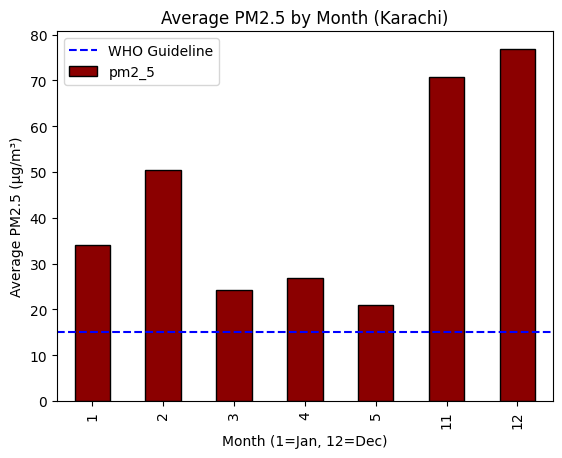

In [12]:
df['month'] = df['event_timestamp'].dt.month
monthly_pm25 = df.groupby('month')['pm2_5'].mean()
monthly_pm25.plot(kind='bar', color='darkred', edgecolor='black')
plt.title('Average PM2.5 by Month (Karachi)')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.axhline(y=15, color='blue', linestyle='--', label='WHO Guideline')
plt.legend()
plt.show()

In [13]:
df['season'] = pd.cut(df['month'], bins=[0, 2, 5, 8, 11, 12], 
                       labels=['Winter', 'Spring', 'Summer', 'Fall', 'Winter'])
seasonal_aqi = df.groupby('season', observed=False)['aqi_is_poor'].mean() * 100
seasonal_aqi.plot(kind='bar', color=['blue', 'green', 'orange', 'brown', 'blue'])
plt.title('% of Time AQI is Poor by Season')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

ValueError: labels must be unique if ordered=True; pass ordered=False for duplicate labels

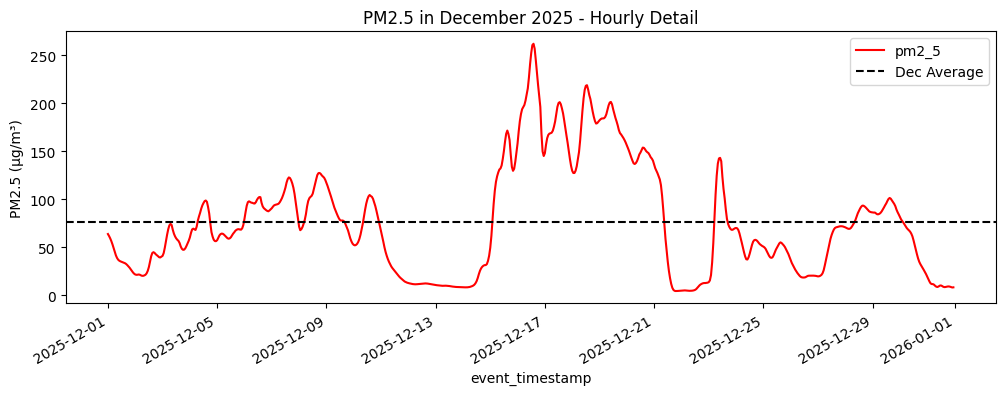

December PM2.5 stats:
  Max: 262.0 µg/m³
  Mean: 76.9 µg/m³
  % days > WHO: 83.9%


In [14]:
december = df[df['month'] == 12]
december.set_index('event_timestamp')['pm2_5'].plot(figsize=(12,4), color='red')
plt.title('PM2.5 in December 2025 - Hourly Detail')
plt.ylabel('PM2.5 (µg/m³)')
plt.axhline(y=december['pm2_5'].mean(), color='black', linestyle='--', label='Dec Average')
plt.legend()
plt.show()

print(f"December PM2.5 stats:")
print(f"  Max: {december['pm2_5'].max():.1f} µg/m³")
print(f"  Mean: {december['pm2_5'].mean():.1f} µg/m³")
print(f"  % days > WHO: {(december['pm25_exceeds_who'].mean()*100):.1f}%")

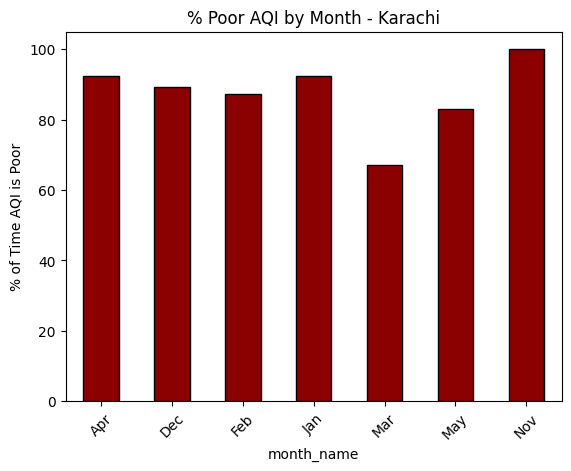

In [15]:
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
df['month_name'] = df['month'].map(month_names)

monthly_aqi = df.groupby('month_name')['aqi_is_poor'].mean() * 100
monthly_aqi.plot(kind='bar', color='darkred', edgecolor='black')
plt.title('% Poor AQI by Month - Karachi')
plt.ylabel('% of Time AQI is Poor')
plt.xticks(rotation=45)
plt.show()